# Locomotion Mode CNN Classifier

**Dataset:** CAMARGO (Georgia Tech, 2021) — Subject AB06  
**Input:** Thigh IMU (6 channels: Accel XYZ + Gyro XYZ) at 200 Hz  
**Classes:** Walk (levelground) / Ramp / Stair  
**Architecture:** 1D CNN → deployable on microcontroller  
**Goal:** Prototype classifier, retrain later on WAWA exoskeleton data  

---

**Future WAWA input config:**  
Tailbone IMU (6) + hip angles L/R (2) + hip angular velocities L/R (2) = 10 channels  

**To expand later:**  
- 5 classes: walk / stair ascent / stair descent / ramp ascent / ramp descent  
- Cross-subject generalization with more CAMARGO subjects  
- Swap in WAWA data when collected

## 0. Imports & Setup

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

%matplotlib inline
plt.rcParams['figure.dpi'] = 140
plt.rcParams['font.size'] = 9

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
  GPU: NVIDIA RTX A5000


## 1. Inspect Data Structure

CAMARGO `.mat` files were converted to CSV using MATLAB.  
Each CSV has 25 columns: Header (time) + 4 body segments × 6 channels (Accel XYZ, Gyro XYZ).  
Segments: foot, shank, **thigh** (our target), trunk.

In [2]:
DATA_DIR = os.path.expanduser(
    '~/repos/projects/exo-assist-pipeline/data/camargo/AB06/10_09_18')

# Check available modes
modes = [d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))]
print(f'Available modes: {modes}')

# Count CSV files per mode
for mode in ['levelground', 'ramp', 'stair']:
    csvs = glob.glob(os.path.join(DATA_DIR, mode, 'imu', '*.csv'))
    print(f'  {mode}: {len(csvs)} CSV files')

Available modes: ['levelground', 'treadmill', 'stair', 'static', 'ramp']
  levelground: 30 CSV files
  ramp: 63 CSV files
  stair: 42 CSV files


In [3]:
# Inspect one CSV
sample_csv = glob.glob(os.path.join(DATA_DIR, 'levelground', 'imu', '*.csv'))[0]
df = pd.read_csv(sample_csv)
print(f'File: {os.path.basename(sample_csv)}')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'\nSample rate: {1/(df["Header"].diff().median()):.0f} Hz')
print(f'Duration: {df["Header"].iloc[-1] - df["Header"].iloc[0]:.1f} s')
df.head()

File: levelground_ccw_slow_04_01.csv
Shape: (4287, 25)
Columns: ['Header', 'foot_Accel_X', 'foot_Accel_Y', 'foot_Accel_Z', 'foot_Gyro_X', 'foot_Gyro_Y', 'foot_Gyro_Z', 'shank_Accel_X', 'shank_Accel_Y', 'shank_Accel_Z', 'shank_Gyro_X', 'shank_Gyro_Y', 'shank_Gyro_Z', 'thigh_Accel_X', 'thigh_Accel_Y', 'thigh_Accel_Z', 'thigh_Gyro_X', 'thigh_Gyro_Y', 'thigh_Gyro_Z', 'trunk_Accel_X', 'trunk_Accel_Y', 'trunk_Accel_Z', 'trunk_Gyro_X', 'trunk_Gyro_Y', 'trunk_Gyro_Z']

Sample rate: 200 Hz
Duration: 21.4 s


,Header,foot_Accel_X,foot_Accel_Y,foot_Accel_Z,foot_Gyro_X,foot_Gyro_Y,foot_Gyro_Z,shank_Accel_X,shank_Accel_Y,shank_Accel_Z,...,thigh_Accel_Z,thigh_Gyro_X,thigh_Gyro_Y,thigh_Gyro_Z,trunk_Accel_X,trunk_Accel_Y,trunk_Accel_Z,trunk_Gyro_X,trunk_Gyro_Y,trunk_Gyro_Z
0,8.925,-1.037483,0.590182,0.924216,1.534943,5.514039,-0.803788,-0.750747,0.036937,-0.671247,...,0.142784,0.503106,0.919862,1.592533,-0.965873,0.008826,-0.466419,-1.012534,-0.191335,0.076217
1,8.930,-1.075412,0.453063,0.873488,1.433367,5.519304,-0.898707,-0.833824,0.054294,-0.591313,...,0.174394,0.716606,0.886923,1.666500,-0.953847,-0.010486,-0.442091,-1.353517,-0.452914,0.022654
2,8.935,-1.050806,0.487376,0.830302,1.491755,5.519885,-0.930240,-1.014993,0.043604,-0.416334,...,0.255724,0.877440,0.806493,1.798961,-0.949230,-0.048297,-0.431655,-1.579034,-0.597522,-0.028800
3,8.940,-1.068386,0.585161,0.826320,1.563352,5.523406,-0.915862,-1.150829,0.005407,-0.292196,...,0.294435,0.903535,0.730953,1.902863,-0.961978,-0.095698,-0.394336,-1.735977,-0.695129,-0.061747
4,8.945,-1.058199,0.593769,0.819588,1.595694,5.499154,-0.906300,-1.194446,0.000862,-0.265982,...,0.336042,0.849874,0.641454,2.000884,-0.974229,-0.167016,-0.342638,-1.789490,-0.787881,-0.081526


## 2. Configuration

Define the target columns, windowing parameters, and class labels.

In [4]:
# === CONFIGURATION ===

# Target IMU columns (thigh segment)
THIGH_COLS = ['thigh_Accel_X', 'thigh_Accel_Y', 'thigh_Accel_Z',
              'thigh_Gyro_X', 'thigh_Gyro_Y', 'thigh_Gyro_Z']
N_CH = len(THIGH_COLS)  # 6

# Windowing
FS = 200          # Hz
WIN_SEC = 0.2     # 200ms window
STEP_SEC = 0.1    # 100ms step (50% overlap)
WIN = int(FS * WIN_SEC)    # 40 samples
STEP = int(FS * STEP_SEC)  # 20 samples

# Labels (3-class for now)
LABEL_MAP = {'levelground': 0, 'ramp': 1, 'stair': 2}
LABELS = ['walk', 'ramp', 'stair']
N_CLASSES = len(LABELS)

print(f'Channels: {N_CH} ({THIGH_COLS})')
print(f'Window: {WIN} samples = {WIN_SEC*1000:.0f}ms')
print(f'Step: {STEP} samples = {STEP_SEC*1000:.0f}ms (50% overlap)')
print(f'Classes: {LABELS}')

Channels: 6 (['thigh_Accel_X', 'thigh_Accel_Y', 'thigh_Accel_Z', 'thigh_Gyro_X', 'thigh_Gyro_Y', 'thigh_Gyro_Z'])
Window: 40 samples = 200ms
Step: 20 samples = 100ms (50% overlap)
Classes: ['walk', 'ramp', 'stair']


## 3. Load All Trials

Load CSV files from levelground, ramp, and stair IMU folders.

In [5]:
trials = []
for mode in ['levelground', 'ramp', 'stair']:
    csv_files = sorted(glob.glob(os.path.join(DATA_DIR, mode, 'imu', '*.csv')))
    for f in csv_files:
        df = pd.read_csv(f)
        data = df[THIGH_COLS].values.astype(np.float32)
        trials.append((data, mode, os.path.basename(f)))

print(f'Loaded {len(trials)} trials')
print(f'By mode: {Counter([t[1] for t in trials])}')
print(f'Sample shape: {trials[0][0].shape} (n_samples, {N_CH} channels)')

# Duration stats
durations = {m: [] for m in LABEL_MAP}
for data, mode, _ in trials:
    durations[mode].append(data.shape[0] / FS)
for m, durs in durations.items():
    print(f'  {m}: {len(durs)} trials, '
          f'duration={np.mean(durs):.1f} ± {np.std(durs):.1f}s')

Loaded 135 trials
By mode: Counter({'ramp': 63, 'stair': 42, 'levelground': 30})
Sample shape: (3068, 6) (n_samples, 6 channels)
  levelground: 30 trials, duration=20.6 ± 5.0s
  ramp: 63 trials, duration=17.3 ± 1.8s
  stair: 42 trials, duration=15.1 ± 1.0s


## 4. Visualize Raw IMU Data

Plot one trial per locomotion mode to sanity-check the data.

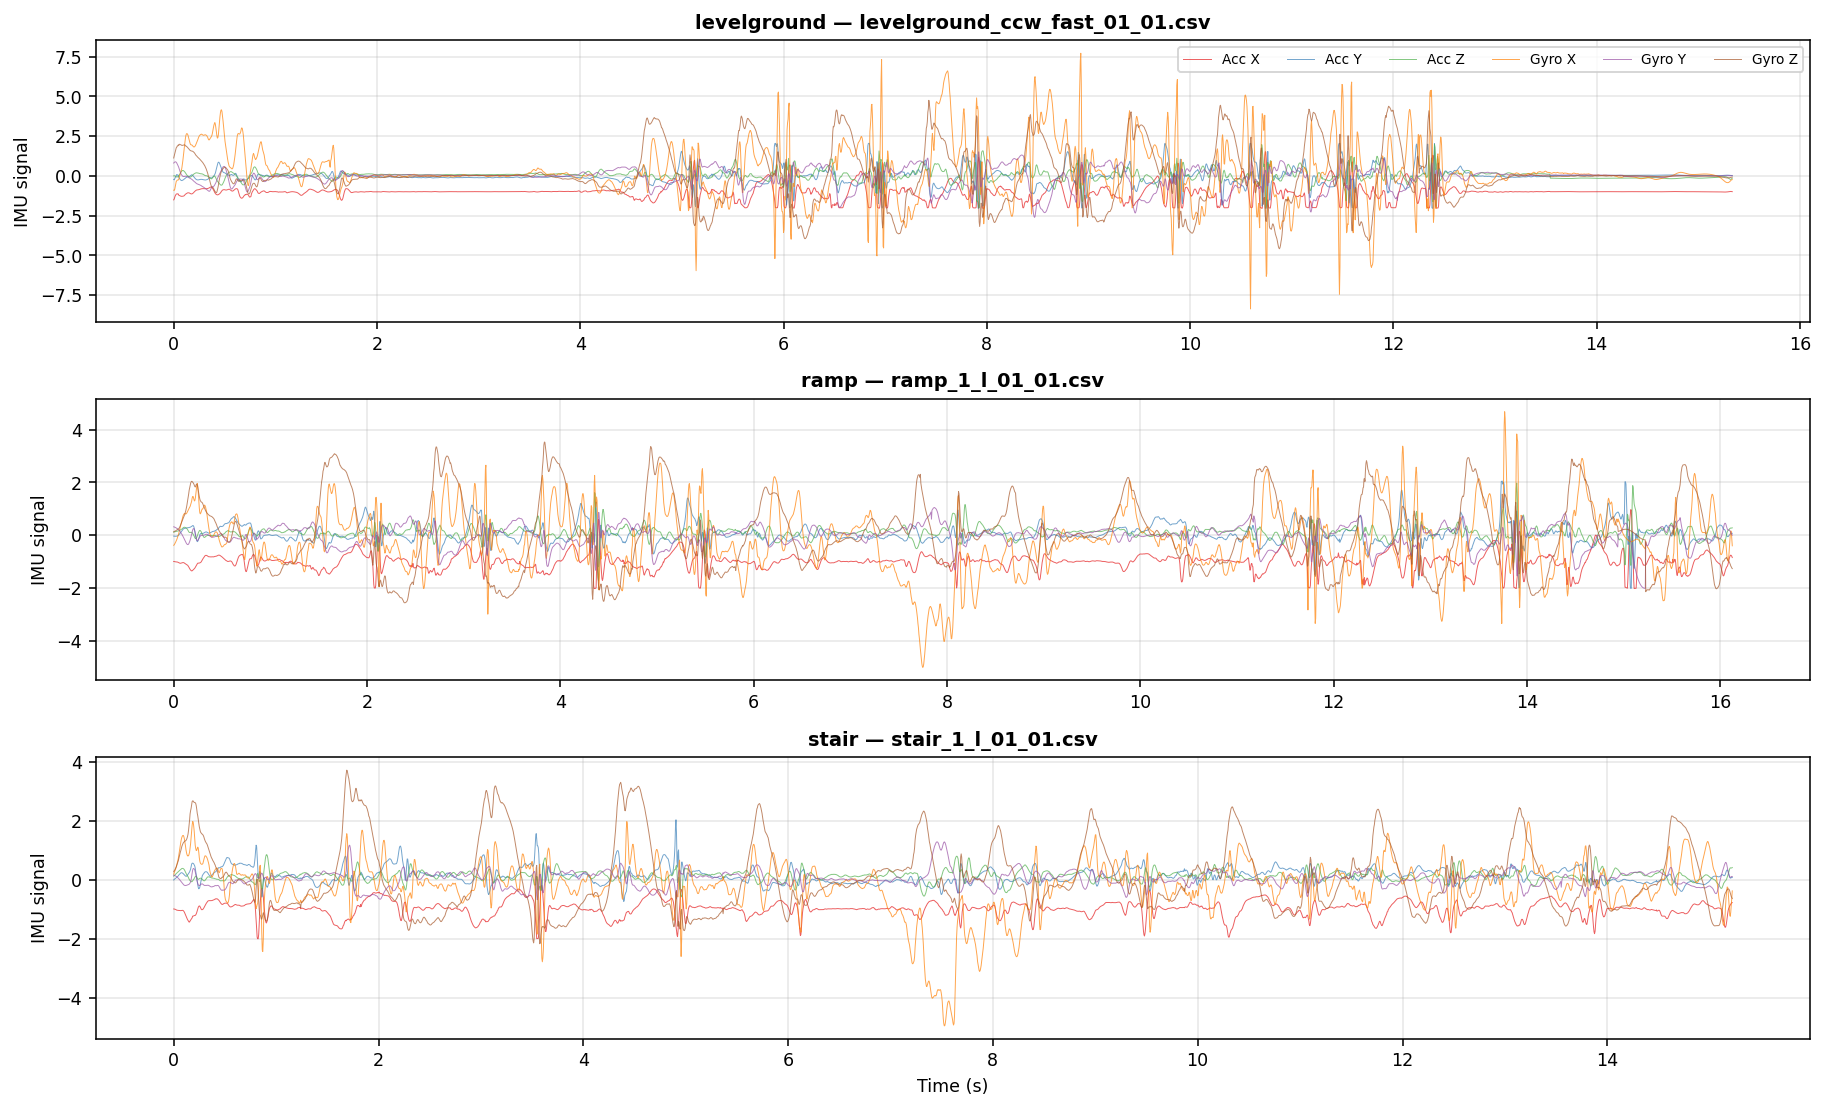

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=False)
ch_labels = ['Acc X', 'Acc Y', 'Acc Z', 'Gyro X', 'Gyro Y', 'Gyro Z']
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#ff7f00', '#984ea3', '#a65628']

for ax, mode in zip(axes, ['levelground', 'ramp', 'stair']):
    trial = next(t for t in trials if t[1] == mode)
    data = trial[0]
    t = np.arange(data.shape[0]) / FS
    for ch in range(N_CH):
        ax.plot(t, data[:, ch], lw=0.5, alpha=0.7, color=colors[ch], label=ch_labels[ch])
    ax.set_title(f'{mode} — {trial[2]}', fontsize=10, fontweight='bold')
    ax.set_ylabel('IMU signal')
    ax.grid(True, alpha=0.3)

axes[0].legend(ncol=6, fontsize=7, loc='upper right')
axes[-1].set_xlabel('Time (s)')
fig.tight_layout()
plt.show()

## 5. Create Sliding Windows

Extract fixed-length windows from each trial.  
Output shape: `(n_windows, n_channels, window_size)` for PyTorch Conv1d.

In [7]:
Xw, yw = [], []
for data, mode, _ in trials:
    lab = LABEL_MAP[mode]
    for s in range(0, data.shape[0] - WIN + 1, STEP):
        window = data[s:s + WIN, :].T  # (6, 40) — channels first
        Xw.append(window)
        yw.append(lab)

X = np.array(Xw, dtype=np.float32)
y = np.array(yw, dtype=np.int64)

print(f'X: {X.shape}  (n_windows, n_channels, window_size)')
print(f'y: {y.shape}')
print(f'Class distribution:')
for i, name in enumerate(LABELS):
    count = (y == i).sum()
    print(f'  {name}: {count} ({count/len(y)*100:.1f}%)')

X: (23202, 6, 40)  (n_windows, n_channels, window_size)
y: (23202,)
Class distribution:
  walk: 6126 (26.4%)
  ramp: 10788 (46.5%)
  stair: 6288 (27.1%)


## 6. Normalize & Split

Per-channel z-score normalization, then 80/20 train/test split.

In [8]:
# Per-channel normalization
X_mean = X.mean(axis=(0, 2), keepdims=True)  # (1, 6, 1)
X_std = X.std(axis=(0, 2), keepdims=True) + 1e-8
X_norm = (X - X_mean) / X_std

print(f'After normalization: mean≈{X_norm.mean():.4f}, std≈{X_norm.std():.4f}')

# Train/test split (stratified)
Xtr, Xte, ytr, yte = train_test_split(
    X_norm, y, test_size=0.2, random_state=42, stratify=y)

print(f'\nTrain: {Xtr.shape[0]} windows')
print(f'Test:  {Xte.shape[0]} windows')

After normalization: mean≈-0.0000, std≈1.0000

Train: 18561 windows
Test:  4641 windows


## 7. Define CNN Model

3-block 1D CNN with global average pooling.  
Small enough for microcontroller deployment (~18K parameters).

```
Input (6, 40)
  → Conv1d(6→32, k=5) + BN + ReLU + MaxPool(2)    → (32, 20)
  → Conv1d(32→64, k=5) + BN + ReLU + MaxPool(2)   → (64, 10)
  → Conv1d(64→128, k=3) + BN + ReLU + AvgPool(→1) → (128,)
  → Dropout + FC(128→64) + ReLU + Dropout + FC(64→3)
```

In [9]:
class LocomotionCNN(nn.Module):
    """1D CNN for locomotion mode classification from thigh IMU."""
    
    def __init__(self, n_channels=6, n_classes=3):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: (n_ch, 40) → (32, 20)
            nn.Conv1d(n_channels, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
            # Block 2: (32, 20) → (64, 10)
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            # Block 3: (64, 10) → (128, 1)
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, n_classes),
        )
    
    def forward(self, x):
        x = self.features(x)       # (batch, 128, 1)
        x = x.squeeze(-1)          # (batch, 128)
        x = self.classifier(x)     # (batch, n_classes)
        return x


model = LocomotionCNN(n_channels=N_CH, n_classes=N_CLASSES).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f'Parameters: {n_params:,}')
print(f'Microcontroller-friendly: {"yes" if n_params < 500_000 else "maybe"}')
print()
print(model)

Parameters: 44,899
Microcontroller-friendly: yes

LocomotionCNN(
  (features): Sequential(
    (0): Conv1d(6, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool1d(output_size=1)
  )
  (classifier): Sequential(
    (0): Dropout(p=0.3, inplace=False)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, in

## 8. Train

Weighted cross-entropy to handle class imbalance.  
ReduceLROnPlateau scheduler for adaptive learning rate.

In [11]:
# DataLoaders
train_dl = DataLoader(
    TensorDataset(torch.from_numpy(Xtr), torch.from_numpy(ytr)),
    batch_size=64, shuffle=True)
test_dl = DataLoader(
    TensorDataset(torch.from_numpy(Xte), torch.from_numpy(yte)),
    batch_size=128)

# Weighted loss for class imbalance
counts = np.bincount(ytr)
weights = torch.FloatTensor(len(counts) / (len(counts) * counts)).to(device)
print(f'Class weights: {dict(zip(LABELS, weights.cpu().numpy()))}')

# Optimizer & scheduler
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(weight=weights)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=5, factor=0.5)

Class weights: {'walk': np.float32(0.00020403998), 'ramp': np.float32(0.00011587486), 'stair': np.float32(0.00019880716)}


In [12]:
# Training loop
N_EPOCHS = 40
history = {'train_loss': [], 'test_loss': [], 'test_acc': []}

for epoch in range(N_EPOCHS):
    # --- Train ---
    model.train()
    train_loss = 0
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(xb)
    train_loss /= len(train_dl.dataset)
    
    # --- Evaluate ---
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for xb, yb in test_dl:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            test_loss += criterion(out, yb).item() * len(xb)
            correct += (out.argmax(1) == yb).sum().item()
    test_loss /= len(test_dl.dataset)
    test_acc = correct / len(test_dl.dataset)
    scheduler.step(test_loss)
    
    history['train_loss'].append(train_loss)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        lr = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch+1:3d}/{N_EPOCHS}  '
              f'train={train_loss:.4f}  test={test_loss:.4f}  '
              f'acc={test_acc:.3f}  lr={lr:.1e}')

print(f'\n>>> Best test accuracy: {max(history["test_acc"]):.3f}')

Epoch   1/40  train=0.7583  test=0.6418  acc=0.667  lr=1.0e-03
Epoch   5/40  train=0.5120  test=0.4600  acc=0.780  lr=1.0e-03
Epoch  10/40  train=0.4343  test=0.4307  acc=0.786  lr=1.0e-03
Epoch  15/40  train=0.4034  test=0.4320  acc=0.800  lr=1.0e-03
Epoch  20/40  train=0.3792  test=0.3594  acc=0.828  lr=1.0e-03
Epoch  25/40  train=0.3549  test=0.3507  acc=0.831  lr=1.0e-03
Epoch  30/40  train=0.3169  test=0.3115  acc=0.835  lr=5.0e-04
Epoch  35/40  train=0.3031  test=0.3189  acc=0.839  lr=5.0e-04
Epoch  40/40  train=0.2965  test=0.3621  acc=0.837  lr=5.0e-04

>>> Best test accuracy: 0.854


## 9. Training Curves

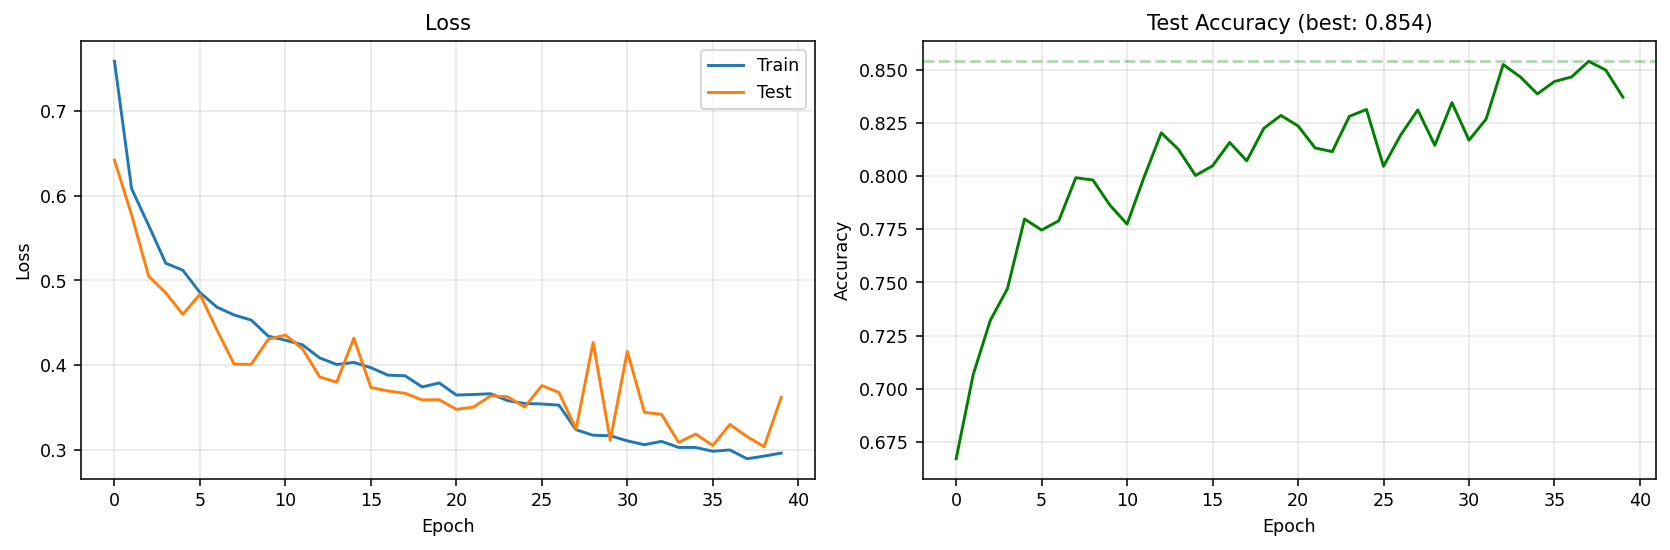

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['train_loss'], label='Train', lw=1.5)
ax1.plot(history['test_loss'], label='Test', lw=1.5)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Loss'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(history['test_acc'], color='green', lw=1.5)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title(f'Test Accuracy (best: {max(history["test_acc"]):.3f})')
ax2.grid(True, alpha=0.3)
ax2.axhline(max(history['test_acc']), color='green', ls='--', alpha=0.3)

fig.tight_layout()
plt.show()

## 10. Confusion Matrix & Classification Report

              precision    recall  f1-score   support

        walk       0.86      0.90      0.88      1225
        ramp       0.87      0.82      0.84      2158
       stair       0.77      0.80      0.78      1258

    accuracy                           0.84      4641
   macro avg       0.83      0.84      0.84      4641
weighted avg       0.84      0.84      0.84      4641



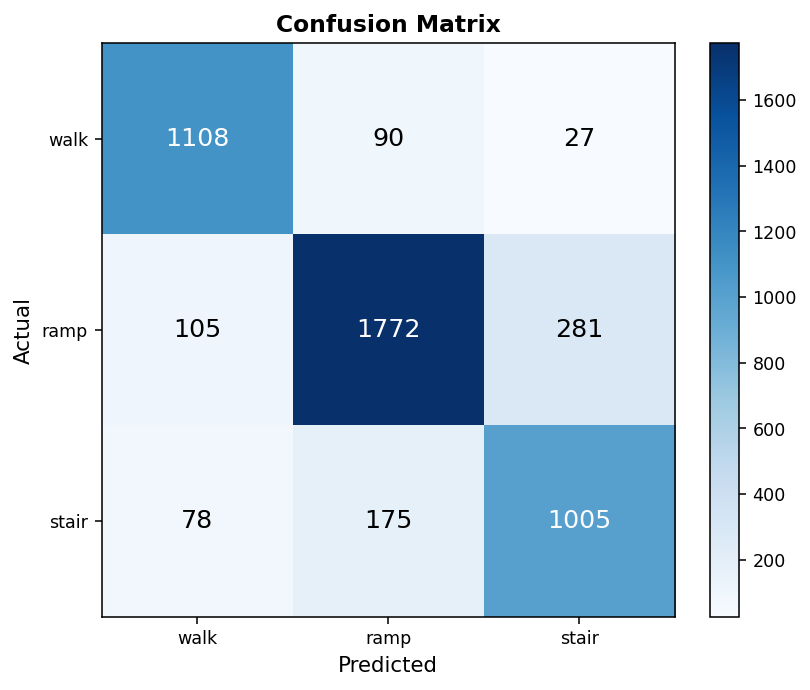

In [14]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_dl:
        preds = model(xb.to(device)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(yb.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Classification report
print(classification_report(all_labels, all_preds, target_names=LABELS))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues', interpolation='nearest')
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        val = cm[i, j]
        ax.text(j, i, str(val), ha='center', va='center', fontsize=13,
                color='white' if val > cm.max() / 2 else 'black')
ax.set_xticks(range(N_CLASSES)); ax.set_yticks(range(N_CLASSES))
ax.set_xticklabels(LABELS); ax.set_yticklabels(LABELS)
ax.set_xlabel('Predicted', fontsize=11); ax.set_ylabel('Actual', fontsize=11)
ax.set_title('Confusion Matrix', fontsize=12, fontweight='bold')
fig.colorbar(im, fraction=0.046)
fig.tight_layout()
plt.show()

## 11. Save Model

In [15]:
save_dir = os.path.expanduser(
    '~/repos/projects/exo-assist-pipeline/models')
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, 'locomotion_cnn_v1.pt')
torch.save({
    'model_state_dict': model.state_dict(),
    'config': {
        'n_channels': N_CH,
        'n_classes': N_CLASSES,
        'window_size': WIN,
        'sample_rate': FS,
        'window_sec': WIN_SEC,
        'step_sec': STEP_SEC,
    },
    'label_names': LABELS,
    'thigh_columns': THIGH_COLS,
    'normalization': {
        'mean': X_mean,
        'std': X_std,
    },
    'best_test_accuracy': max(history['test_acc']),
    'history': history,
}, save_path)

print(f'Model saved to: {save_path}')
print(f'Test accuracy: {max(history["test_acc"]):.3f}')
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Model saved to: /home/wxp/repos/projects/exo-assist-pipeline/models/locomotion_cnn_v1.pt
Test accuracy: 0.854
Parameters: 44,899


## 12. Quick Inference Demo

Show how to use the trained model on a new IMU window.

In [16]:
def predict_window(model, window, x_mean, x_std):
    """
    Predict locomotion mode from a single IMU window.
    
    Args:
        model: trained LocomotionCNN
        window: numpy array (6, 40) — thigh IMU data
        x_mean, x_std: normalization parameters
    
    Returns:
        predicted class name, confidence scores
    """
    model.eval()
    # Normalize
    w = (window - x_mean.squeeze(0)) / x_std.squeeze(0)  # (6, 40)
    # To tensor
    x = torch.from_numpy(w).unsqueeze(0).float().to(device)  # (1, 6, 40)
    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
    pred_idx = probs.argmax()
    return LABELS[pred_idx], {LABELS[i]: f'{p:.3f}' for i, p in enumerate(probs)}

# Test on a random window from each class
for cls_idx, cls_name in enumerate(LABELS):
    mask = yte == cls_idx
    sample_window = Xte[mask][0]  # already normalized
    # Undo normalization for the function (it re-normalizes)
    raw_window = sample_window * X_std.squeeze(0) + X_mean.squeeze(0)
    pred, probs = predict_window(model, raw_window, X_mean, X_std)
    status = '✓' if pred == cls_name else '✗'
    print(f'{status} True: {cls_name:6s} → Predicted: {pred:6s}  {probs}')

✗ True: walk   → Predicted: ramp    {'walk': '0.368', 'ramp': '0.556', 'stair': '0.076'}
✓ True: ramp   → Predicted: ramp    {'walk': '0.000', 'ramp': '0.988', 'stair': '0.012'}
✓ True: stair  → Predicted: stair   {'walk': '0.000', 'ramp': '0.000', 'stair': '1.000'}


---

## Next Steps

1. **5-class expansion** — use `conditions/` files to separate ramp/stair into ascent/descent
2. **Add goniometer channels** — load `gon/` CSVs for hip angle (proxy for motor encoder)
3. **More subjects** — download AB09, AB10 etc. for cross-subject evaluation
4. **Collect WAWA data** — tailbone IMU (6) + motor encoder angles/vels (4) + EMG (4)
5. **Swap data loader** — replace CAMARGO CSV loading with WAWA data format
6. **Integrate with gait phase** — combine Yang's φ(t) with CNN output for full classifier
7. **Deploy** — export to ONNX/TFLite for microcontroller inference